**Objective:**
This notebook analyzes raw telemetry data from a gas turbine engine to identify operational correlations and precursor signatures of mechanical faults. The dataset includes high-frequency logs of Turbine Inlet Temperature, RPM, Torque, and Vibrational data.

**Key Analytical Steps:**
1. **Data Ingestion & Cleaning:** Checked for any NaN or Null value in the dataset.
2. **Thermal & Efficiency Profiling:** Mapped the relationship between Temperature and Power Output to establish the baseline operational envelope.
3. **Fault Isolation:** Segmented the data by operational status (`Fault = 0` vs `Fault = 1`) to compare dynamic mechanical responses.

**Preliminary Findings:**
* **Vibrational Signatures:** Initial scatter plot analysis comparing RPM and Torque against Vibrations reveals overlapping clusters. Fault states (1) do not appear exclusively isolated to raw high-magnitude vibrations at the current sample rate.
* **Trend Deviation:** Trend lines applied to the Torque vs. Vibration distributions suggest that while the absolute values overlap, the *operational path* of the turbine differs during a fault state.

**Engineering Next Steps (Future Work):**
Because mechanical faults often manifest in the *rate of change* rather than absolute magnitude, future iterations of this pipeline should feature:
* **Derivative Analysis:** Calculating `d(Vibration)/dt` to isolate sudden mechanical shocks.
* **Frequency Domain Analysis:** Applying Fast Fourier Transforms (FFT) to the vibration data to look for specific harmonic frequencies that can lead to failure.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('gas_turbine_fault_detection.csv')
print("Total columns: ", len(df.columns))
print("Column Names: ")
for col in df.columns:
    print("----> " + col)

print("\nChecking if any column has null values: \n")
print(df.isnull().any())

In [ ]:
abs_max_temp=df['Temperature (°C)'].max()
print("Absolute Maximum Temperature Reached: ", abs_max_temp)

In [ ]:
danger_zone=df[(df['Temperature (°C)']>df['Temperature (°C)'].quantile(.90)) & (df['RPM']>df['RPM'].mean())]
print("Number of stress test instances: ", len(danger_zone))
print("Potentially stressed instances: \n", danger_zone[['Temperature (°C)', 'RPM', 'Power Output (MW)', 'Fault']])

In [ ]:
grouped_faults = df.groupby('Fault').mean()
print("\nAverage values for each fault type: \n", grouped_faults)

In [ ]:
df['Temp_Kelvin']= df['Temperature (°C)'] + 273.15
df['Pressure_Ratio']= df['Air Pressure (kPa)'] / df['Air Pressure (kPa)'].min()

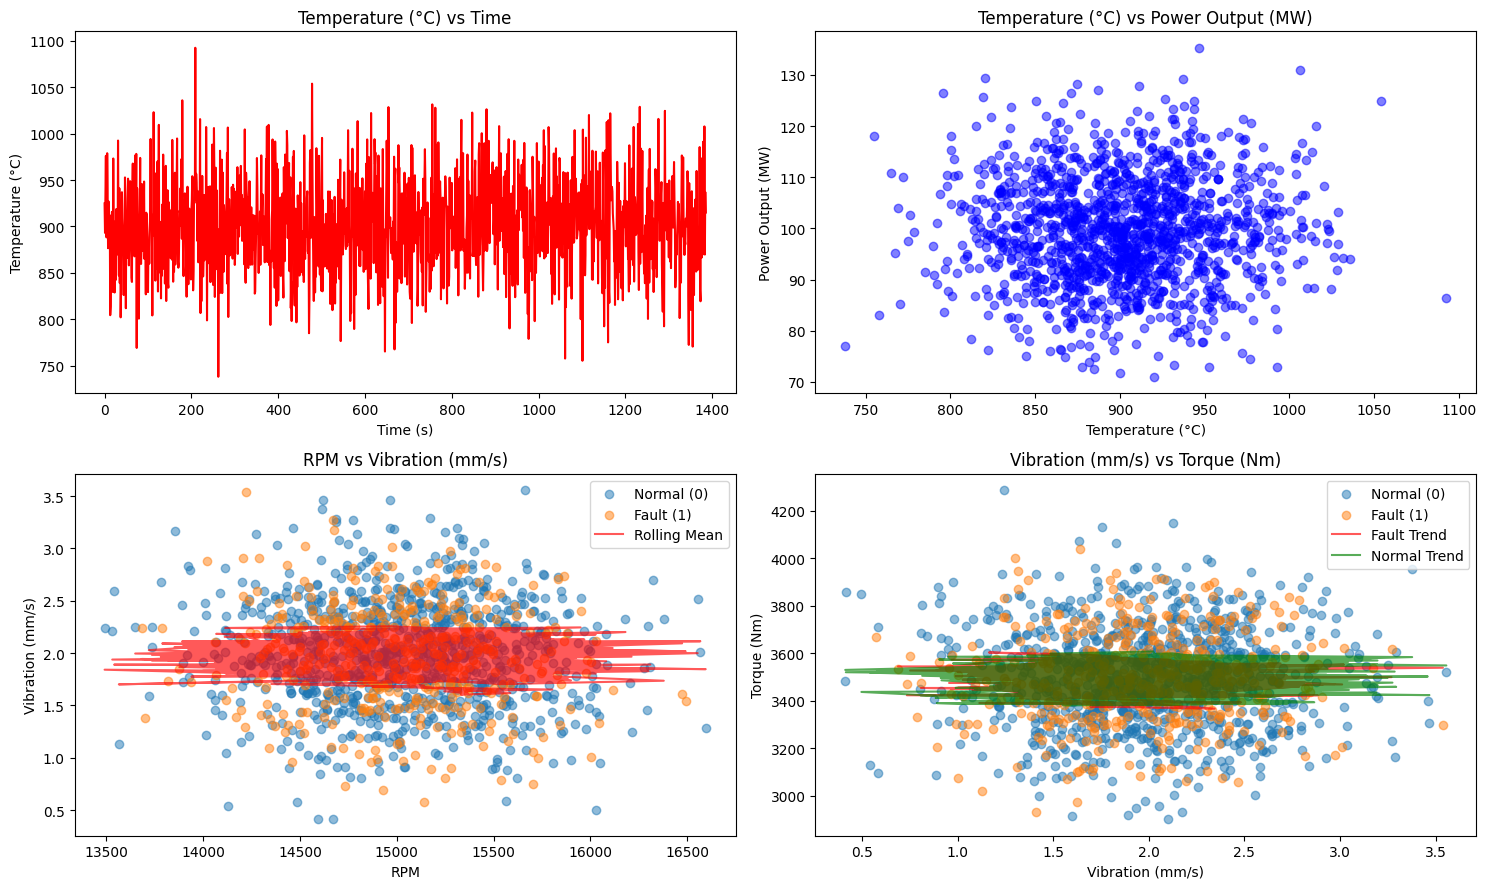

In [92]:
main_plot=plt.figure(figsize=(15,9))
plot1=main_plot.add_subplot(2,2,1)

plot1.plot(df.index, df['Temperature (°C)'], color='red')
plot1.set_title("Temperature (°C) vs Time")
plot1.set_xlabel("Time (s)")
plot1.set_ylabel("Temperature (°C)")    
plot1.plot()

plot2=main_plot.add_subplot(2,2,2)
plot2.scatter(df['Temperature (°C)'], df['Power Output (MW)'], color='blue', alpha=0.5)
plot2.set_title("Temperature (°C) vs Power Output (MW)")
plot2.set_xlabel("Temperature (°C)")
plot2.set_ylabel("Power Output (MW)")
plot2.plot()

plot3 = main_plot.add_subplot(2,2,3)
plot3.scatter(df[df['Fault']==0]['RPM'], df[df['Fault']==0]['Vibrations (mm/s)'], alpha=0.5, label='Normal (0)')
plot3.scatter(df[df['Fault']==1]['RPM'], df[df['Fault']==1]['Vibrations (mm/s)'], alpha=0.5, label='Fault (1)')
plot3.plot(df['RPM'], df['Vibrations (mm/s)'].rolling(window=20).mean(), color='red', linewidth=1.5, alpha=0.65, label='Rolling Mean')
plot3.set_title("RPM vs Vibration (mm/s)")
plot3.set_xlabel("RPM")
plot3.set_ylabel("Vibration (mm/s)")
plot3.legend()

plot4 = main_plot.add_subplot(2,2,4)
plot4.scatter(df[df['Fault']==0]['Vibrations (mm/s)'], df[df['Fault']==0]['Torque (Nm)'], alpha=0.5, label='Normal (0)')
plot4.scatter(df[df['Fault']==1]['Vibrations (mm/s)'], df[df['Fault']==1]['Torque (Nm)'], alpha=0.5, label='Fault (1)')
plot4.plot(df[df['Fault']==1]['Vibrations (mm/s)'], df[df['Fault']==1]['Torque (Nm)'].rolling(window=20).mean(), color='red', linewidth=1.5, alpha=0.65, label='Fault Trend')
plot4.plot(df[df['Fault']==0]['Vibrations (mm/s)'], df[df['Fault']==0]['Torque (Nm)'].rolling(window=20).mean(), color='green', linewidth=1.5, alpha=0.65, label='Normal Trend')
plot4.set_title("Vibration (mm/s) vs Torque (Nm)")
plot4.set_xlabel("Vibration (mm/s)")
plot4.set_ylabel("Torque (Nm)")
plot4.legend()

plt.tight_layout()


